In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Đảm bảo biểu đồ hiển thị mượt mà ngay trong notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# Đường dẫn đến file dữ liệu
data_path = "datasets/Base.csv"          

# Đọc dữ liệu
df = pd.read_csv(data_path)
# Hiển thị 5 dòng đầu tiên
print("--- 5 dòng đầu tiên của dữ liệu ---")
print(df.head())

--- 5 dòng đầu tiên của dữ liệu ---
   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89            20            0.010095   
2                            14            40            0.012316   
3                            14            30            0.006991   
4                            29            40            5.742626   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0              102.4

In [18]:
print("--- Thông tin chi tiết về các thuộc tính (Features) ---")
df.info()

--- Thông tin chi tiết về các thuộc tính (Features) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-n

--- Thống kê nhãn Gian lận (fraud_bool) ---
  + Hợp pháp (Legit): 988,971 hồ sơ (98.90%)
  + Gian lận (Fraud): 11,029 hồ sơ (1.10%)


C:\Users\vuanh\AppData\Local\Temp\ipykernel_18976\4146112040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='fraud_bool', data=df, palette='Set2')


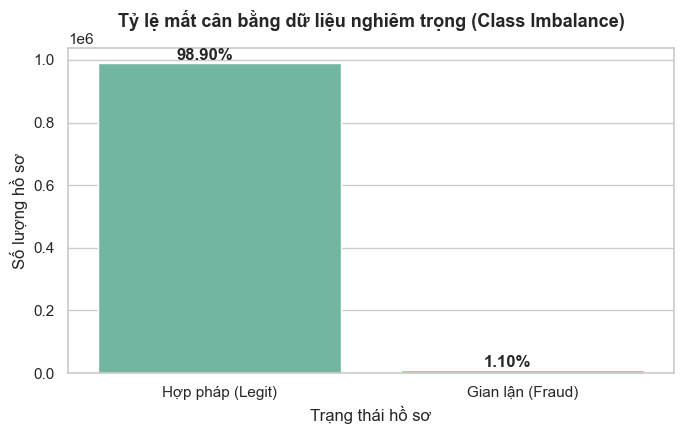

In [19]:
# Thống kê số lượng và tỷ lệ %
fraud_counts = df['fraud_bool'].value_counts()
fraud_percentages = df['fraud_bool'].value_counts(normalize=True) * 100

print("--- Thống kê nhãn Gian lận (fraud_bool) ---")
for val, count in fraud_counts.items():
    label = "Gian lận (Fraud)" if val == 1 else "Hợp pháp (Legit)"
    print(f"  + {label}: {count:,} hồ sơ ({fraud_percentages[val]:.2f}%)")

# Vẽ biểu đồ cột trực quan hóa mức độ lệch dữ liệu
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x='fraud_bool', data=df, palette='Set2')

# Chèn thêm số liệu phần trăm ngay trên đầu cột để tăng tính chuyên nghiệp
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.05
    y_coord = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x_coord, y_coord), ha='center', weight='bold')

plt.title('Tỷ lệ mất cân bằng dữ liệu nghiêm trọng (Class Imbalance)', fontsize=13, weight='bold', pad=15)
plt.xticks([0, 1], ['Hợp pháp (Legit)', 'Gian lận (Fraud)'])
plt.xlabel('Trạng thái hồ sơ')
plt.ylabel('Số lượng hồ sơ')
plt.tight_layout()
plt.show()

In [20]:
print("\n--- Bắt đầu quá trình Tiền xử lý dữ liệu ---")

# 1. Xác định các cột dạng chữ (Categorical features)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"📌 Các cột dạng chữ cần xử lý One-Hot Encoding: {categorical_cols}")

# 2. Thực hiện One-Hot Encoding tự động bằng pandas (Tránh gán nhãn thứ tự sai lệch)
df_preprocessed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"✅ Mã hóa xong. Kích thước dữ liệu mới sau biến đổi: {df_preprocessed.shape[0]:,} dòng và {df_preprocessed.shape[1]} cột.")

# 3. Tách Đặc trưng (X) và Nhãn mục tiêu (y)
X = df_preprocessed.drop(columns=['fraud_bool'])
y = df_preprocessed['fraud_bool']

# Lần 1: Chia thành tập Train (70%) và tập Tạm thời (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  # Đảm bảo tỷ lệ Fraud đồng đều giữa các tập
)

# Lần 2: Chia tập Tạm thời thành Valid (15%) và Test (15%) theo tỷ lệ 50/50
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(f"\n📊 Kết quả chia tập dữ liệu thành công:")
print(f"  + Tập Train (Dùng để huấn luyện mô hình): {X_train.shape[0]:,} dòng")
print(f"  + Tập Valid (Dùng để tối ưu hóa tham số): {X_valid.shape[0]:,} dòng")
print(f"  + Tập Test (Dùng để đánh giá độc lập cuối cùng): {X_test.shape[0]:,} dòng")





--- Bắt đầu quá trình Tiền xử lý dữ liệu ---
📌 Các cột dạng chữ cần xử lý One-Hot Encoding: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
✅ Mã hóa xong. Kích thước dữ liệu mới sau biến đổi: 1,000,000 dòng và 48 cột.

📊 Kết quả chia tập dữ liệu thành công:
  + Tập Train (Dùng để huấn luyện mô hình): 700,000 dòng
  + Tập Valid (Dùng để tối ưu hóa tham số): 150,000 dòng
  + Tập Test (Dùng để đánh giá độc lập cuối cùng): 150,000 dòng


In [21]:
# ==============================================================================
# CELL 5: HUẤN LUYỆN MÔ HÌNH RANDOM FOREST VỚI CLASS WEIGHT
# ==============================================================================
print("\n⏳ Đang khởi tạo và huấn luyện mô hình Random Forest (Có thể mất 1-2 phút)...")
start_time = time.time()

# Khởi tạo mô hình chuyên trị dữ liệu lệch cho Bank
# n_estimators=50: Chạy 50 cây quyết định để tối ưu tốc độ cho dự án cá nhân
# class_weight='balanced': Tự động phạt nặng khi đoán sai mẫu gian lận ít ỏi
rf_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)

# Huấn luyện mô hình trên tập dữ liệu Train
rf_model.fit(X_train, y_train)

end_time = time.time()
print(f"✅ Đã huấn luyện xong mô hình trong {end_time - start_time:.2f} giây!")



⏳ Đang khởi tạo và huấn luyện mô hình Random Forest (Có thể mất 1-2 phút)...
✅ Đã huấn luyện xong mô hình trong 11.78 giây!


In [22]:
# ==============================================================================
# CELL 6: DỰ ĐOÁN THỬ NGHIỆM TRÊN TẬP VALIDATION
# ==============================================================================
print("\n🔮 Tiến hành dự đoán thử nghiệm trên tập Validation để kiểm tra hiệu năng ban đầu...")
y_valid_pred = rf_model.predict(X_valid)
y_valid_proba = rf_model.predict_proba(X_valid)[:, 1]

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
print(classification_report(y_valid, y_valid_pred))
print(f"ROC-AUC Score trên tập Valid: {roc_auc_score(y_valid, y_valid_proba):.4f}")


🔮 Tiến hành dự đoán thử nghiệm trên tập Validation để kiểm tra hiệu năng ban đầu...

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    148345
           1       0.00      0.00      0.00      1655

    accuracy                           0.99    150000
   macro avg       0.49      0.50      0.50    150000
weighted avg       0.98      0.99      0.98    150000

ROC-AUC Score trên tập Valid: 0.7810


In [23]:
# ==============================================================================
# CELL 7: TỐI ƯU HÓA NGƯỠNG QUYẾT ĐỊNH (THRESHOLD TUNING)
# ==============================================================================
from sklearn.metrics import precision_recall_curve

print("--- Tiến hành tối ưu hóa Ngưỡng quyết định ---")

# 1. Thử nghiệm nhanh với một ngưỡng thấp cố định (Ví dụ: 0.03 - tức là trên 3% xác suất là nghi ngờ)
test_threshold = 0.03
y_valid_pred_adjusted = (y_valid_proba >= test_threshold).astype(int)

print(f"\n📊 KẾT QUẢ ĐÁNH GIÁ VỚI NGƯỠNG HẠ XUỐNG: {test_threshold} (3%)")
print(classification_report(y_valid, y_valid_pred_adjusted))

# 2. Tự động tìm kiếm ngưỡng tối ưu nhất dựa trên điểm F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_valid_proba)

# Tính F1-score cho từng ngưỡng toán học để tìm điểm cân bằng tốt nhất
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n🎯 Ngưỡng tối ưu nhất tính toán được dựa trên F1-Score: {best_threshold:.4f}")

# Dự đoán lại toàn bộ tập Validation với ngưỡng tối ưu nhất vừa tìm được
y_valid_pred_best = (y_valid_proba >= best_threshold).astype(int)

print(f"\n🏆 KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG VỚI NGƯỠNG TỐI ƯU ({best_threshold:.4f}):")
print(classification_report(y_valid, y_valid_pred_best))

--- Tiến hành tối ưu hóa Ngưỡng quyết định ---

📊 KẾT QUẢ ĐÁNH GIÁ VỚI NGƯỠNG HẠ XUỐNG: 0.03 (3%)
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    148345
           1       0.06      0.53      0.10      1655

    accuracy                           0.90    150000
   macro avg       0.53      0.72      0.53    150000
weighted avg       0.98      0.90      0.94    150000


🎯 Ngưỡng tối ưu nhất tính toán được dựa trên F1-Score: 0.1200

🏆 KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG VỚI NGƯỠNG TỐI ƯU (0.1200):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    148345
           1       0.19      0.19      0.19      1655

    accuracy                           0.98    150000
   macro avg       0.59      0.59      0.59    150000
weighted avg       0.98      0.98      0.98    150000



In [24]:
# ==============================================================================
# CELL 8: ÁP DỤNG KỸ THUẬT SMOTE (UPSAMPLING) TRÊN TẬP TRAIN
# ==============================================================================
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"📊 Phân bố nhãn tập Train BAN ĐẦU: {Counter(y_train)}")

# 1. Khởi tạo SMOTE với tỷ lệ mong muốn 
# (Ví dụ: sampling_strategy=0.1 nghĩa là tạo mẫu lớp 1 bằng 10% số lượng lớp 0, 
# không nên tăng lên hẳn 50/50 vì dữ liệu sẽ bị quá ảo so với thực tế ngân hàng)
smote = SMOTE(sampling_strategy=0.1, random_state=42)

# 2. CHỈ fit_resample trên tập huấn luyện (X_train, y_train)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"🚀 Phân bố nhãn tập Train SAU KHI SMOTE: {Counter(y_train_resampled)}")

# 3. Huấn luyện lại mô hình với dữ liệu mới đã được cân bằng hơn
print("\n⏳ Đang huấn luyện lại mô hình Random Forest với dữ liệu SMOTE...")
rf_model_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_smote.fit(X_train_resampled, y_train_resampled)

# 4. Dự đoán thử nghiệm trên tập Validation (Tập Valid giữ nguyên không SMOTE)
y_valid_pred_smote = rf_model_smote.predict(X_test) # Chấm điểm độc lập
y_valid_proba_smote = rf_model_smote.predict_proba(X_test)[:, 1]

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SAU KHI ÁP DỤNG SMOTE ---")
print(classification_report(y_test, y_valid_pred_smote))
print(f"ROC-AUC Score mới: {roc_auc_score(y_test, y_valid_proba_smote):.4f}")

📊 Phân bố nhãn tập Train BAN ĐẦU: Counter({0: 692280, 1: 7720})
🚀 Phân bố nhãn tập Train SAU KHI SMOTE: Counter({0: 692280, 1: 69228})

⏳ Đang huấn luyện lại mô hình Random Forest với dữ liệu SMOTE...

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SAU KHI ÁP DỤNG SMOTE ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    148346
           1       0.26      0.03      0.05      1654

    accuracy                           0.99    150000
   macro avg       0.62      0.51      0.52    150000
weighted avg       0.98      0.99      0.98    150000

ROC-AUC Score mới: 0.8206


In [25]:
# ==============================================================================
# KHỐI KẾT HỢP: HUẤN LUYỆN SMOTE VÀ TỰ ĐỘNG TÌM NGƯỠNG TỐI ƯU
# ==============================================================================
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score
import numpy as np

print("--- 🥇 GIAI ĐOẠN 1: HUẤN LUYỆN MÔ HÌNH VỚI SMOTE ---")
# 1. Chỉ thực hiện SMOTE trên tập Train để chống rò rỉ dữ liệu (Data Leakage)
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. Huấn luyện mô hình Random Forest trên dữ liệu đã cân bằng
rf_model_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model_smote.fit(X_train_resampled, y_train_resampled)

# 3. Lấy xác suất dự đoán trên tập TEST độc lập
y_test_proba_smote = rf_model_smote.predict_proba(X_test)[:, 1]
print(f"✅ Mô hình SMOTE đạt điểm nội tại ROC-AUC: {roc_auc_score(y_test, y_test_proba_smote):.4f}")


print("\n--- 🎯 GIAI ĐOẠN 2: TỰ ĐỘNG DÒ TÌM NGƯỠNG TOÁN HỌC TỐI ƯU ---")
# 4. Tính toán đường cong Precision-Recall dựa trên xác suất của mô hình SMOTE
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba_smote)

# 5. Tìm ngưỡng có điểm F1-Score cao nhất
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx_smote = np.argmax(f1_scores)
best_threshold_smote = thresholds[best_idx_smote]

print(f"🥇 Ngưỡng toán học hoàn hảo nhất tính riêng cho mô hình SMOTE là: {best_threshold_smote:.4f}")


print("\n--- 🏆 GIAI ĐOẠN 3: ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP ---")
# 6. Ép mô hình phân loại theo ngưỡng tối ưu vừa tìm được
y_test_pred_final = (y_test_proba_smote >= best_threshold_smote).astype(int)

# In bảng điểm cuối cùng để viết vào CV
print(classification_report(y_test, y_test_pred_final))

--- 🥇 GIAI ĐOẠN 1: HUẤN LUYỆN MÔ HÌNH VỚI SMOTE ---
✅ Mô hình SMOTE đạt điểm nội tại ROC-AUC: 0.8206

--- 🎯 GIAI ĐOẠN 2: TỰ ĐỘNG DÒ TÌM NGƯỠNG TOÁN HỌC TỐI ƯU ---
🥇 Ngưỡng toán học hoàn hảo nhất tính riêng cho mô hình SMOTE là: 0.2400

--- 🏆 GIAI ĐOẠN 3: ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    148346
           1       0.15      0.18      0.16      1654

    accuracy                           0.98    150000
   macro avg       0.57      0.58      0.58    150000
weighted avg       0.98      0.98      0.98    150000



⏳ Đang trích xuất các đặc trưng quan trọng từ mô hình SMOTE Random Forest...


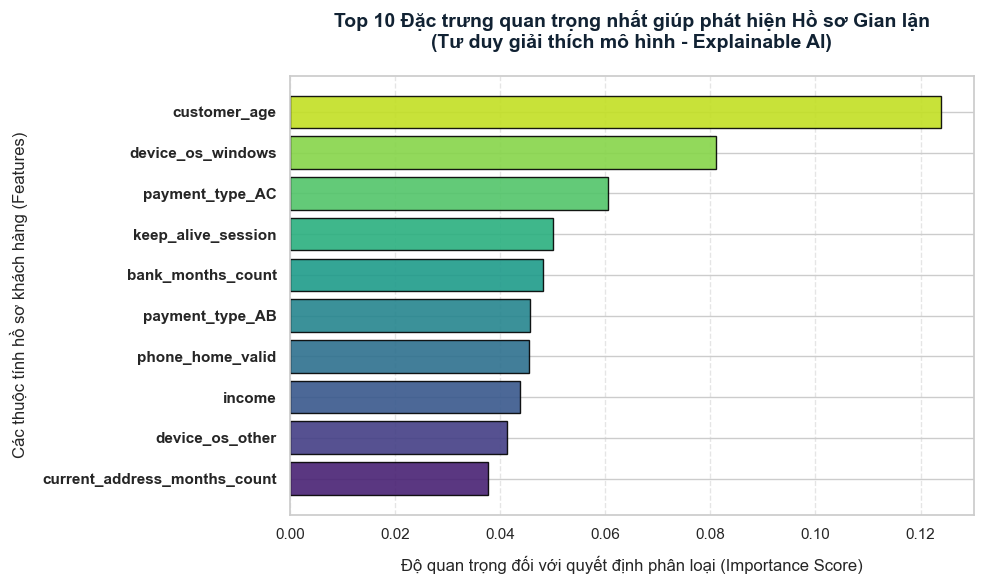

✅ Đã trực quan hóa xong Top 10 đặc trưng cốt lõi cấu thành hành vi rủi ro!


In [26]:
# ==============================================================================
# CELL 10: PHÂN TÍCH VÀ TRỰC QUAN HÓA ĐẶC TRƯNG QUAN TRỌNG (FEATURE IMPORTANCE) - ĐÃ SỬA LỖI
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang trích xuất các đặc trưng quan trọng từ mô hình SMOTE Random Forest...")

# 1. Lấy độ quan trọng (importance scores) của tất cả các cột dữ liệu
importances = rf_model_smote.feature_importances_
feature_names = X.columns

# 2. Sắp xếp thứ tự giảm dần và chọn ra Top 10 đặc trưng lớn nhất
indices = np.argsort(importances)[-10:]

# 3. Tiến hành vẽ biểu đồ thanh ngang chuyên nghiệp
plt.figure(figsize=(10, 6))
# Sử dụng bảng màu phối hợp trang nhã
colors = sns.color_palette("viridis", len(indices))
plt.barh(range(len(indices)), importances[indices], align='center', color=colors, edgecolor='black', alpha=0.9)

# Gắn nhãn tên các cột dữ liệu tương ứng vào trục Y
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11, weight='bold')

# SỬA LỖI TẠI ĐÂY: Đổi 'pad' thành 'labelpad' cho xlabel và ylabel
plt.xlabel('Độ quan trọng đối với quyết định phân loại (Importance Score)', fontsize=12, labelpad=10)
plt.ylabel('Các thuộc tính hồ sơ khách hàng (Features)', fontsize=12, labelpad=10)

# Đối với title thì tham số 'pad' vẫn giữ nguyên vì matplotlib hỗ trợ thuộc tính này
plt.title('Top 10 Đặc trưng quan trọng nhất giúp phát hiện Hồ sơ Gian lận\n(Tư duy giải thích mô hình - Explainable AI)', 
          fontsize=14, weight='bold', pad=20, color='#112233')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ Đã trực quan hóa xong Top 10 đặc trưng cốt lõi cấu thành hành vi rủi ro!")

In [27]:
# ==============================================================================
# CELL 11: ĐÀO SÂU NGHIỆP VỤ - PHÂN TÍCH TÁC ĐỘNG ĐỊNH HƯỚNG CỦA CÁC FEATURE
# ==============================================================================
print("--- 🔍 PHÂN TÍCH CHI TIẾT HÀNH VI GIAN LẬN (BUSINESS INSIGHTS) --- \n")

# Lấy danh sách Top 5 đặc trưng quan trọng nhất từ biểu đồ của bạn
top_5_features = ['customer_age', 'device_os_windows', 'payment_type_AC', 'keep_alive_session', 'bank_months_count']

for col in top_5_features:
    if col in df_preprocessed.columns:
        # Tính toán giá trị trung bình của cột đó đối với hồ sơ Sạch (0) và hồ sơ Gian lận (1)
        mean_legit = df_preprocessed[df_preprocessed['fraud_bool'] == 0][col].mean()
        mean_fraud = df_preprocessed[df_preprocessed['fraud_bool'] == 1][col].mean()
        
        print(f"📌 Thuộc tính: [{col}]")
        print(f"  + Trung bình ở hồ sơ Hợp pháp: {mean_legit:.4f}")
        print(f"  + Trung bình ở hồ sơ Gian lận: {mean_fraud:.4f}")
        
        # Đưa ra nhận định định hướng
        if mean_fraud > mean_legit:
            print(f"  🚨 Ý nghĩa: Chỉ số này CÀNG CAO thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.\n")
        else:
            print(f"  📉 Ý nghĩa: Chỉ số này CÀNG THẤP thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.\n")

--- 🔍 PHÂN TÍCH CHI TIẾT HÀNH VI GIAN LẬN (BUSINESS INSIGHTS) --- 

📌 Thuộc tính: [customer_age]
  + Trung bình ở hồ sơ Hợp pháp: 33.6091
  + Trung bình ở hồ sơ Gian lận: 40.8586
  🚨 Ý nghĩa: Chỉ số này CÀNG CAO thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.

📌 Thuộc tính: [device_os_windows]
  + Trung bình ở hồ sơ Hợp pháp: 0.2599
  + Trung bình ở hồ sơ Gian lận: 0.5900
  🚨 Ý nghĩa: Chỉ số này CÀNG CAO thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.

📌 Thuộc tính: [payment_type_AC]
  + Trung bình ở hồ sơ Hợp pháp: 0.2506
  + Trung bình ở hồ sơ Gian lận: 0.3816
  🚨 Ý nghĩa: Chỉ số này CÀNG CAO thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.

📌 Thuộc tính: [keep_alive_session]
  + Trung bình ở hồ sơ Hợp pháp: 0.5796
  + Trung bình ở hồ sơ Gian lận: 0.3416
  📉 Ý nghĩa: Chỉ số này CÀNG THẤP thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.

📌 Thuộc tính: [bank_months_count]
  + Trung bình ở hồ sơ Hợp pháp: 10.8434
  + Trung bình ở hồ sơ Gian lận: 10.4696
  📉 Ý nghĩa: Chỉ số này CÀNG THẤP thì hồ sơ CÀNG CÓ XU HƯỚNG GIAN LẬN.



In [28]:
# ==============================================================================
# CELL 12: ĐÓNG GÓI VÀ LƯU MÔ HÌNH (EXPORT MODEL)
# ==============================================================================
import joblib

# Tạo một thư mục hoặc lưu trực tiếp file mô hình
model_filename = "rf_fraud_model.pkl"
features_filename = "model_features.pkl"

# 1. Lưu trọng số mô hình Random Forest
joblib.dump(rf_model_smote, model_filename)

# 2. Lưu danh sách cấu trúc các cột đặc trưng sau khi mã hóa One-Hot
joblib.dump(X.columns.tolist(), features_filename)

print(f"✅ Đã đóng gói và xuất file thành công!")
print(f"  + File mô hình: {model_filename}")
print(f"  + File cấu trúc đặc trưng: {features_filename}")

✅ Đã đóng gói và xuất file thành công!
  + File mô hình: rf_fraud_model.pkl
  + File cấu trúc đặc trưng: model_features.pkl


🚀 Đang khởi chạy tiến trình Benchmarking: Huấn luyện XGBoost...

📊 --- KẾT QUẢ ĐỐI SÁNH HIỆU NĂNG GỐC (ROC-AUC) ---
🌲 Random Forest + SMOTE: ROC-AUC = 0.8206
⚡ XGBoost + SMOTE:       ROC-AUC = 0.8728


d:\App\Anacoda1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\App\Anacoda1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\App\Anacoda1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\App\Anacoda1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


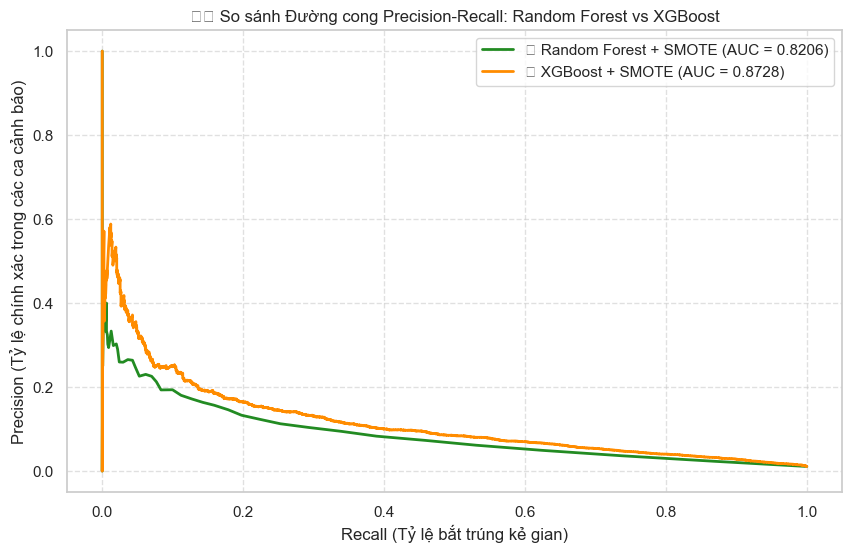

In [30]:
# ==========================================================================
# CẢI TIẾN 2: MODEL BENCHMARKING (RANDOM FOREST VS XGBOOST WITH SMOTE)
# ==========================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

print("🚀 Đang khởi chạy tiến trình Benchmarking: Huấn luyện XGBoost...")

# 1. Khởi tạo và huấn luyện mô hình XGBoost với biến chuẩn từ file của bạn
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
# Đã sửa thành X_train_resampled cho khớp 100% với cell SMOTE phía trên
xgb_model.fit(X_train_resampled, y_train_resampled)

# 2. Dự đoán xác suất trên tập kiểm thử độc lập (Test Set)
y_pred_proba_rf = rf_model_smote.predict_proba(X_test)[:, 1] # Đã sửa thành rf_model_smote
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]     # Xác suất của XGBoost mới

# 3. Tính toán điểm số ROC-AUC của cả 2 ứng viên
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n📊 --- KẾT QUẢ ĐỐI SÁNH HIỆU NĂNG GỐC (ROC-AUC) ---")
print(f"🌲 Random Forest + SMOTE: ROC-AUC = {auc_rf:.4f}")
print(f"⚡ XGBoost + SMOTE:       ROC-AUC = {auc_xgb:.4f}")

# 4. Trực quan hóa đường cong Precision-Recall Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(recall_rf, precision_rf, label=f'🌲 Random Forest + SMOTE (AUC = {auc_rf:.4f})', color='forestgreen', lw=2)
plt.plot(recall_xgb, precision_xgb, label=f'⚡ XGBoost + SMOTE (AUC = {auc_xgb:.4f})', color='darkorange', lw=2)

plt.xlabel('Recall (Tỷ lệ bắt trúng kẻ gian)')
plt.ylabel('Precision (Tỷ lệ chính xác trong các ca cảnh báo)')
plt.title('⚖️ So sánh Đường cong Precision-Recall: Random Forest vs XGBoost')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [31]:
import joblib

# Lưu đè mô hình XGBoost mới vào đúng tên file cũ để đỡ phải sửa code cấu hình tên file
joblib.dump(xgb_model, "rf_fraud_model.pkl") 
print("✅ Đã xuất mô hình XGBoost mới thành công dưới tên 'rf_fraud_model.pkl'!")

✅ Đã xuất mô hình XGBoost mới thành công dưới tên 'rf_fraud_model.pkl'!
